# TDDE70 lab 3: Graph Neural Networks
The aim with this lab is that you get to familiarize yourself a bit more with graph neural networks (GNNs). You will use the message passing neural network-framework presented in the lectures and which you worked on in the prepatory exercises, but mostly you will put this into practice and implement a GNN using [PyTorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/#) (PyG), which is a library built on top of PyTorch for working with GNNs of all kinds, and which you have also seen in the prepatory exercises. 

**NOTE**: For this lab, use the conda environment called ```lab3```.

## Load required packages

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric as pyg
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
from utils import load_toy_data, generate_otf_graph

from coll_data import get_coll_loaders, batch_to_atoms

import ase

## Task 0: Data and batching in PyG
PyG is built on top of PyTorch, and in that sense is very similar to what you have already seen. However, graphs are structured a bit differently compared to, e.g., images. For example, the sizes of different samples can be very different, and a graph consists of different parts like node features, edges, and edge features. PyG helps keeping track and organize this using ```pyg.data.Data``` (for a single instance of a graph) and ```pyg.loader.DataLoader``` (a custom DataLoader for batching data).

### Data
First, lets take a look at two toy graphs, illustrated below. The numbers represent indices, and the colors indicate the type of the node (i.e. we have discrete node features represented by the different colors).

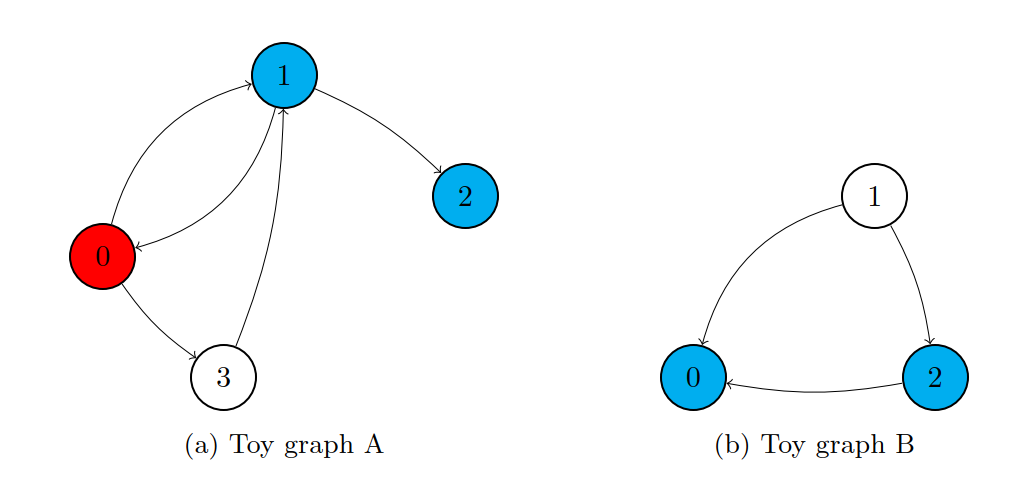



PyG representations of these can be loaded using ```load_toy_data()``` which returns the two graphs as ```pyg.data.Data``` objects. Try printing the contents, then answer the questions below.


In [2]:
data1, data2 = load_toy_data()

In [ ]:
# play around
print(data1)
print(data2)

Data(x=[4, 1], edge_index=[2, 5])
Data(x=[3, 1], edge_index=[2, 3])


**Question:** Which of ```data1``` and ```data2``` correspond to graph A and B? Include a short motivation based on the output of your code.

**Answer:**

graph_A = data1
graph_B = data2

We can see this according to their shapes. data1 has 5 edges for example, and data2 has 3.

### Batching
Now, let's take a look at how batching works in PyG. Create a PyG dataloader with ```data1``` and ```data2``` and 
check the content of the resulting batch to answer the two questions below.

In [7]:
# create dataloader
dataloader = pyg.loader.DataLoader([data1, data2], batch_size=2)
data_batch = next(iter(dataloader))

In [8]:
# play around with data_batch
print(data_batch)

DataBatch(x=[7, 1], edge_index=[2, 8], batch=[7], ptr=[3])


**Question**: What is the purpose of the ```batch``` attribute in ```data_batch```?

**Answer:**

To see what batch (original graph) each node comes from. 

**Question**: What happened to ```edge_index``` when batching the two graphs? Why?

**Answer**:

We had edge_indexes [2, 5] and [2, 3] before and now [2, 8] so basically we just added the 2nd dimension together. Basically we know we have 8 edges now.

# Task 1: Implementing a CGCNN layer
In the prepatory exercises, you derived the MPNN equations for CGCNN, which is the model that we will work with in this lab. Now it is time to put these equations into practice and create a CGCNN layer, using the ```MessagePassing``` class from PyG and which you also saw in the prepatory exercises.

Implement the equations that you derived in the ``CGCNNLayer`` class below. In the CGCNN paper, it is specified that $\sigma(\cdot) = \text{sigmoid}(\cdot)$ implements a _gating_ mechanism: as the output of sigmoid is limited to be between 0 and 1, this part essentially determines how much of each channel of the output of $g(\cdot)$ that should be kept. For $g(\cdot)$, we can use $\text{softplus}(\cdot)$.

**NOTE:** The use of `update` has according to the developers been phased out, and the update is instead handled inside the `forward` function, using the output of `propagate` (see also the prepatory exercises).

### Using BatchNorm
It is not specified in the paper, but in the official implementation of CGCNN, batch norm is used on two occasions:
1. Before $\sigma$ and $g$ are applied
2. On the result of the sum

In other words, the equation in the paper should read (modifications showed by $\color{red}{\text{red}}$ color):


$$
\mathbf{h}_i^{(l+1)}  = \mathbf{h}_i^{(l)} + \text{\color{red}{BN}}\textcolor{red}{\bigg(}\sum_{j\in\mathcal{N}(i)}\sigma\Big(\text{\color{red}{BN}}\textcolor{red}{(}W_f^{(l)}\mathbf{z}^{(l)}_{i,j} + b_f^{(l)}\textcolor{red}{)}\Big)\odot g\Big(\text{\color{red}{BN}}\textcolor{red}{(}W_s^{(l)}\mathbf{z}_{i,j}^{(l)} + b_s^{(l)}\textcolor{red}{)}\Big)\textcolor{red}{\bigg)}
$$

and this is what we will use.

In [ ]:
class CGCNNLayer(pyg.nn.MessagePassing):
    def __init__(self, node_fea_dim, edge_fea_dim): #node_fea_dim = 64, edge_fea_dim = 10
        # choose appropiate aggregation function
        super().__init__(aggr="sum")  # aggregation function of messages

        # Set up necessary components for one layer
        self.batchNormOut = pyg.nn.BatchNorm(node_fea_dim)
        
        #*2 because h_i and h_j have same feature dim
        z_dim = 2 * node_fea_dim + edge_fea_dim
        
        self.gate = torch.nn.Sequential(
            nn.Linear(z_dim, node_fea_dim),
            pyg.nn.BatchNorm(node_fea_dim),
            nn.Sigmoid()
        )
        
        self.signal = torch.nn.Sequential(
            nn.Linear(z_dim, node_fea_dim),
            pyg.nn.BatchNorm(node_fea_dim),
            nn.Softplus()
        )
        

    def forward(self, h, edge_index, edge_attr):
        # call propagate
        # edge_index always need to be included, then we can add names arguments that will be passed to, e.g., message
        out = self.propagate(edge_index, h=h, e=edge_attr)
        
        # remember batch norm on output from propagate
        out = self.batchNormOut(out)
        # update:
        out = h + out
        # return the updated features:
        return out

    def message(self, h_i, h_j, e):
        # implementation of M_l
        # appending _i or _j to name of a variable that was passed to propagate will map it to the corresponding node
        z = torch.cat([h_i, h_j, e], dim=-1)
        z_gate = self.gate(z)
        z_signal = self.signal(z)
        
        z = torch.mul(z_gate, z_signal)
        return z

## Small check of your implementation

**Question:** Assume you have a batch of two graphs with 12 and 10 nodes, respectively. Let ```h``` be a tensor that contains the hidden node features for your batch, and which is the output of an instance of a CGCNNLayer. Assume each node feature is of dimension 64. What should be the size of ```h```?

**Answer:**

CGCNN preserves dimensionality so input [num_nodes, node_fea_dim] = [22, 64] will give output [22, 64]

In [20]:
# create a random batch of data that could be the out of some intermediate CGCNNLayer
h = torch.randn((130, 64))

edge_feature_dim = 10
edge_features = torch.randn((390, edge_feature_dim))
edge_index = torch.randint(130, (2, 390))

# set up an instance of a CGCNNLayer
layer = CGCNNLayer(64, edge_feature_dim)

In [21]:
# "update" the features by running it through the layer
h_new = layer(h, edge_index, edge_features)

**Question:** What should the following assert statement be? (fill it in and run it)

In [23]:
assert h_new.shape == (130, 64) #(num_nodes, node_fea_dim)

**Question:** What happens when you call the `self.propagate` method?

**Answer:**

# Task 2: Finalizing CGCNN
Now once we have implemented the layer, we can use it in a full CGCNN model. This is still a ```torch.nn.Module``` (so nothing new just because we are working with GNNs), but the layers will be instances of your ```CGCNNLayer``` from before. As such, the ```forward()``` function should do the following (see also the block diagram in the appendix of the prepatory exercises for a visual illustration)

1. Embed the nodes into node features
1. Iterate over the CGCNN layers
    1. Pass through the layer
    1. Batch norm
    1. Activation function (for example, softplus)
1. Pool node features
1. Pass pooled representation through final MLP

To perform the pooling of node features, PyG provides [pooling layers](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#pooling-layers). CGCNN uses mean pooling, so take a look at the documentation of [pyg.nn.pool.global_mean_pool](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.pool.global_mean_pool.html#torch_geometric.nn.pool.global_mean_pool)

**N.B.** The code skeleton is implemented to handle two alternative types of edge features, that we will compare below. By setting  ```edge_fea_dim=1``` we use only distances between atoms as edge features, and by setting ```edge_fea_dim=3``` we use the 3D vectors between atoms as edge features.

In [ ]:
class CGCNN(nn.Module):
    def __init__(self, node_fea_dim, edge_fea_dim, num_layers, cutoff, max_neighbors):
        # feel free to add more arguments if you think it is necessary for your implementation
        super().__init__()
        self.cutoff = cutoff
        self.max_neighbors = max_neighbors
        self.pbc = False  # Keep this when using the COLL dataset
        if edge_fea_dim not in [1, 3]:
            raise ValueError(f"edge_fea_dim={edge_fea_dim} is not supported, needs to be either 1 or 3")
        self.edge_fea_dim = edge_fea_dim

        # Create an embedding layer (the maximum atom number will be less than 100, so use num_embeddings=100 in nn.Embedding)
        
        # Initialize the cgcnn layers, batch norm layers, and choose an activation function
        # Hint: nn.ModuleList can be useful if you don't want to use nn.Sequential

        # Pool function
        self.pool = 
        # Create a small MLP that can take in the pooled representation, and output a prediction of the energy
        self.out_mlp = 

    def forward(self, data):
        # For this data, we construct the graph on the fly, but it is possible for other datasets to have data.edge_index, data.edge_attr etc
        edge_index, edge_dist, distance_vec = generate_otf_graph(data, self.cutoff, self.max_neighbors, self.pbc)
        edge_dist = edge_dist.unsqueeze(-1)
            
        if self.edge_fea_dim == 1:
            edge_attr = edge_dist
        else:
            edge_attr = distance_vec

        # Implement the different steps in the forward pass
        # atomic numbers are stored in data.atomic_numbers

        raise NotImplementedError
            

## Small check of implementation

In [ ]:
# check so that output matches data:

# Get train, val, test loaders with batch size 5, but only use val loader for now. Will download and preprocess data first time
_, loader, _ = get_coll_loaders(5)
data = next(iter(loader))

# init model
model = CGCNN(256, 1, 5, 12, 30)
y_hat = model(data)

assert y_hat.shape == data.y.shape, f"Data shape: {data.y.shape}, output shape: {y_hat.shape}"

## Invariance
In the prepatory exercises you thought about what happens when a molecule is rotated or translated, that this should not alter the energy (the energy is invariant to rotations and translations), and how the choice of edge features creates an invariant network by design. Now let's take a look at this in practice. Load some data and use ```transform_and_visualize``` to apply a rotation and see how it looks like.

**Note**: the dataset we are working on in this lab is called COLL. You do not have to implement the dataset yourself, but PyG provides a custom dataset class called ```InMemoryDataset``` in which COLL has been implemented for this lab. If you are interested in how such a dataset could be constructed, you can take a look at ```coll_data.py``` to see the implementation, and you can read more in the [PyG tutorial on creating graph datasets](https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_dataset.html).

In [ ]:
def transform_and_visualize(data):
    transformed_data = data.clone()
    rot_vec = np.array([1.0, 1.0, 0.0])
    rot_vec = rot_vec / np.linalg.norm(rot_vec)
    rot_angle = np.pi/3
    rotation_matrix = torch.tensor(Rotation.from_rotvec(rot_angle * rot_vec).as_matrix()).float()
    transformed_data.pos = torch.matmul(transformed_data.pos, rotation_matrix)
    fig, ax = plt.subplots(1, 2)
    atoms = batch_to_atoms(data)
    transformed_atoms = batch_to_atoms(transformed_data)

    ase.visualize.plot.plot_atoms(atoms[0], ax[0], rotation=("-75x, 45y, 10z"))
    ase.visualize.plot.plot_atoms(transformed_atoms[0], ax[1], rotation=("-75x, 45y, 10z"))

    ax[0].set_title("Original data")
    ax[1].set_title("Rotated data")
    plt.show()
    return data, transformed_data
    
    

In [ ]:
_, loader, _ = get_coll_loaders(5)  # returns train, val, test loaders with batch size 5. For now just using the val loader. Will download and preprocess data first time

data = next(iter(loader))

data, transformed_data = transform_and_visualize(data)

Now try instatiating a model that uses these different edge features by setting ```edge_fea_dim=1``` (only distances) or ```edge_fea_dim=3``` (vector between atoms), and make predictions for both ```data``` and ```transformed_data```. 

In [ ]:
# Reasonable values for cutoff and max_neighbors are 12 [Å] and 30, respectively. For now, number of layers doesn't matter
model1 = CGCNN(256, 1, 5, 12, 30).eval()
model3 = CGCNN(256, 3, 5, 12, 30).eval()
with torch.no_grad():
    print("Using only distances:")
    print(model1(data), model1(transformed_data), sep="\n")
    print("Using vectors:")
    print(model3(data), model3(transformed_data),sep="\n")

**Question:** What do you see in the outputs? Is it what you expected?

**Answer:**

# Task 3: Train a CGCNN model

## Invariant model
Now it is time to train a model. Start with a completely invariant model (```edge_fea_dim=1```). After loading the data, initialize your model, choose an optimizer and loss function. As mentioned in Lab 1, creating a Trainer class is typically very convenient, but not strictly necessary. You are free to use the very simple train and validate functions below, but you can of course modify the code to implement a trainer yourself.

In [ ]:
train_loader, val_loader, test_loader = get_coll_loaders(128)

In [ ]:
@torch.inference_mode()
def validate(model, loader, device):
    assert not model.training, "Model is in training mode"
    num_samples = 0
    total_sq_error = 0
    total_abs_error = 0
    for i, batch in enumerate(loader):
        batch = batch.to(device)
        batch_size = batch.y.shape[0]
        num_samples += batch_size

        pred = model(batch)
        mae = F.l1_loss(pred, batch.y)
        mse = F.mse_loss(pred, batch.y)

        total_sq_error += mse.item()*batch_size
        total_abs_error += mae.item()*batch_size
    avg_mse = total_sq_error / num_samples
    avg_mae = total_abs_error / num_samples
    return avg_mse, avg_mae

def train_and_test(model, optimizer, loss_fn, train_loader, val_loader, num_epochs=10, device=None, save_name="best_parameters.pt", test_loader=None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)
    model.train(True)
    best_val_error = 1e9

    for epoch in range(num_epochs):
        epoch_losses = []
        for i, batch in enumerate(train_loader):
            optimizer.zero_grad()
            batch = batch.to(device)

            pred = model(batch)

            loss = loss_fn(pred, batch.y)

            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
        mean_epoch_loss = np.mean(epoch_losses)
        print(f"Epoch {epoch + 1} training loss: \t {mean_epoch_loss:.4f}")

        # Validation
        model.train(False)
        val_mse, val_mae = validate(model, val_loader, device) 
        print(f"Epoch {epoch + 1} validation MSE: {val_mse:.4f} \t MAE: {val_mae:.4f}")
        if val_mae < best_val_error:  # we choose MAE as preferred metric
            torch.save(model.state_dict(), save_name)  # save these model parameters
            best_val_error = val_mae
        model.train(True)
    print("Training finished!")
    model.train(False)
    if test_loader is not None:
        print("Evaluating on test set, using model with lowest validation MAE")
        model.load_state_dict(torch.load(save_name))  # load best parameters, based on validation error (early stopping)
        test_mse, test_mae = validate(model, test_loader, device)
        print(f"Final test MSE: {test_mse:.4f}, \t MAE {test_mae:.4f}")

In [ ]:
# Reasonable values for cutoff and max_neighbors are 12 [Å] and 30, respectively
# feel free to play around with number of layers, hidden dimensions, and optimizer
model = CGCNN(256, 1, 5, 12, 30)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = #
train_and_test(model, optimizer, loss_fn, train_loader, val_loader, 15, "cuda", "best_parameters_invariant.pt", test_loader)

**Check for yourself:** The validation error might occasionally spike and become much higher than before, but should in general be similar to the training loss. You should be able to reach a validation MAE of rougly 0.1 \[eV/atom\] after 5-6 epochs, and in 15 epochs be able to reach roughly 0.07 \[eV/atom\].

## Not using an invariant model
Now compare this to a model that is not completely invariant (i.e., ```edge_fea_dim=3```). Use the same setting (model hyperparameters, optimizer, loss) as before. 

In [ ]:
# use same setup as before, only change type of edge features
model = CGCNN(256, 3, 5, 12, 30)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = #
train_and_test(model, optimizer, loss_fn, train_loader, val_loader, 15, "cuda", "best_parameters_non_invariant.pt", test_loader)

**Question:** Do you see any differences in performance compared to the invariant model? Why do you think that is the case?

**Answer:**

**Question:** In this case we could make the model invariant by design. If that is not possible, could you think of some other option(s) for making a model more robust to transformations of the input? (This is relevant for also other models, for example, we might would like to make a CNN robust to rotations of an image, e.g., a cat is always a cat, even if it is rotated)

**Answer:**

# Task 4: Reflection

**Question:** You have now trained a model for predicting the atomization energy of a molecule. What could be a possible use case of such a model? Can you think of other tasks that we could solve using the model developed above (possibly trained on other types of data)?

**Your thoughts:**

**Question:** Developing new technology is often a double-edged sword. Considering the use-case of using a GNN for discovering new materials or molecules, what are potential positive and negative impacts to society?

**Your thoughts**: